<a href="https://colab.research.google.com/github/mbowen36-lab/ECGR-4105/blob/main/ECGR_4105_Homework_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ECGR-4105: Homework 3
Name: Matthew Bowen\
Student ID: 801345379

In [105]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
from IPython.display import display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import SGDClassifier
from sklearn import metrics
import seaborn as sns
from sklearn.metrics import confusion_matrix

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
df_diabetes = pd.read_csv('/content/drive/My Drive/ECGR 4105/Datasets/diabetes.csv')
print(df_diabetes.head())

   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [107]:
df_cancer = pd.read_csv('/content/drive/My Drive/ECGR 4105/Datasets/Cancer.csv')
print(df_cancer.head())

         id diagnosis  radius_mean  texture_mean  perimeter_mean  area_mean  \
0    842302         M        17.99         10.38          122.80     1001.0   
1    842517         M        20.57         17.77          132.90     1326.0   
2  84300903         M        19.69         21.25          130.00     1203.0   
3  84348301         M        11.42         20.38           77.58      386.1   
4  84358402         M        20.29         14.34          135.10     1297.0   

   smoothness_mean  compactness_mean  concavity_mean  concave points_mean  \
0          0.11840           0.27760          0.3001              0.14710   
1          0.08474           0.07864          0.0869              0.07017   
2          0.10960           0.15990          0.1974              0.12790   
3          0.14250           0.28390          0.2414              0.10520   
4          0.10030           0.13280          0.1980              0.10430   

   ...  texture_worst  perimeter_worst  area_worst  smoothness

In [108]:
X = df_diabetes.iloc[:, [0,1,2,3,4,5,6,7]].values
Y = df_diabetes.iloc[:, 8].values

In [109]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

In [110]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [111]:
classifier = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.0, learning_rate='constant', eta0=0.01, random_state=0)

train_loss, test_loss, train_acc, test_acc = [], [], [], []

for epoch in range(200):
    classifier.partial_fit(X_train, Y_train, classes=np.unique(Y_train))
    train_loss.append(metrics.log_loss(Y_train, classifier.predict_proba(X_train)))
    test_loss.append(metrics.log_loss(Y_test, classifier.predict_proba(X_test)))
    train_acc.append(metrics.accuracy_score(Y_train, classifier.predict(X_train)))
    test_acc.append(metrics.accuracy_score(Y_test, classifier.predict(X_test)))

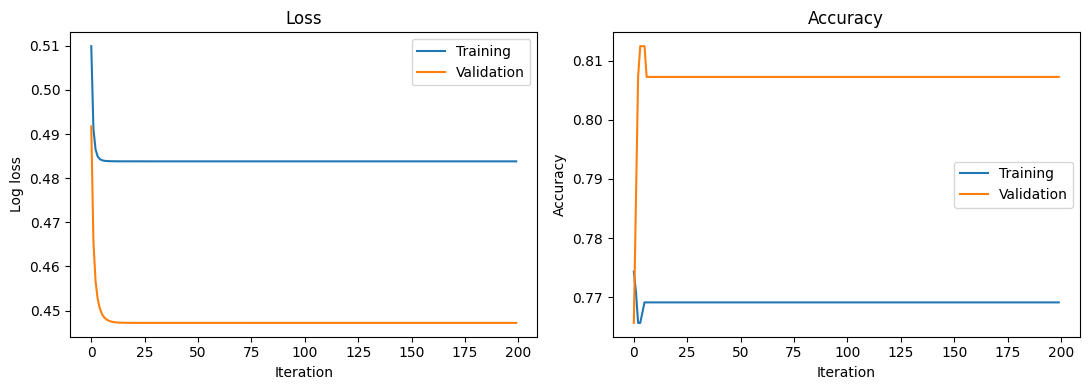

In [112]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(train_loss, label='Training')
ax1.plot(test_loss, label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Log loss')
ax1.legend()

ax2.plot(train_acc, label='Training')
ax2.plot(test_acc, label='Validation')
ax2.set_title('Accuracy')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Accuracy')
ax2.legend()
plt.tight_layout()
plt.show()

In [113]:
Y_pred = classifier.predict(X_test)

In [114]:
cnf_matrix = confusion_matrix(Y_test, Y_pred)
cnf_matrix

array([[119,  11],
       [ 26,  36]])

In [115]:
accuracy = metrics.accuracy_score(Y_test, Y_pred)
precision = metrics.precision_score(Y_test, Y_pred)
recall = metrics.recall_score(Y_test, Y_pred)
f1 = metrics.f1_score(Y_test, Y_pred)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1:",f1)

Accuracy: 0.8072916666666666
Precision: 0.7659574468085106
Recall: 0.5806451612903226
F1: 0.6605504587155964


Text(0.5, 427.9555555555555, 'Predicted label')

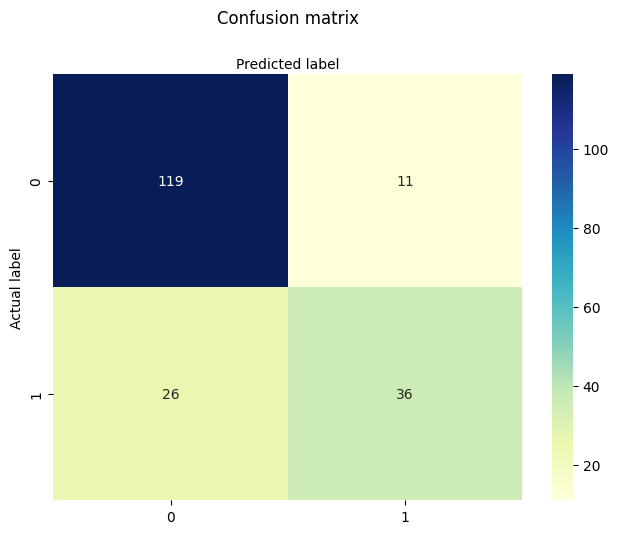

In [116]:
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')

In [117]:
X = df_cancer.iloc[:, [0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31]]
Y = df_cancer.iloc[:, 1].replace({'M': '1', 'B': '0'}).astype(float).values

In [118]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size = 0.25, random_state = 0)

In [119]:
sc_X = StandardScaler()
X_train = sc_X.fit_transform(X_train)
X_test = sc_X.transform(X_test)

In [120]:
classifier = SGDClassifier(loss='log_loss', penalty='l2', alpha=0.01, learning_rate='constant', eta0=0.01, random_state=0)

train_loss, test_loss, train_acc, test_acc = [], [], [], []

for epoch in range(200):
    classifier.partial_fit(X_train, Y_train, classes=np.unique(Y_train))
    train_loss.append(metrics.log_loss(Y_train, classifier.predict_proba(X_train)))
    test_loss.append(metrics.log_loss(Y_test, classifier.predict_proba(X_test)))
    train_acc.append(metrics.accuracy_score(Y_train, classifier.predict(X_train)))
    test_acc.append(metrics.accuracy_score(Y_test, classifier.predict(X_test)))

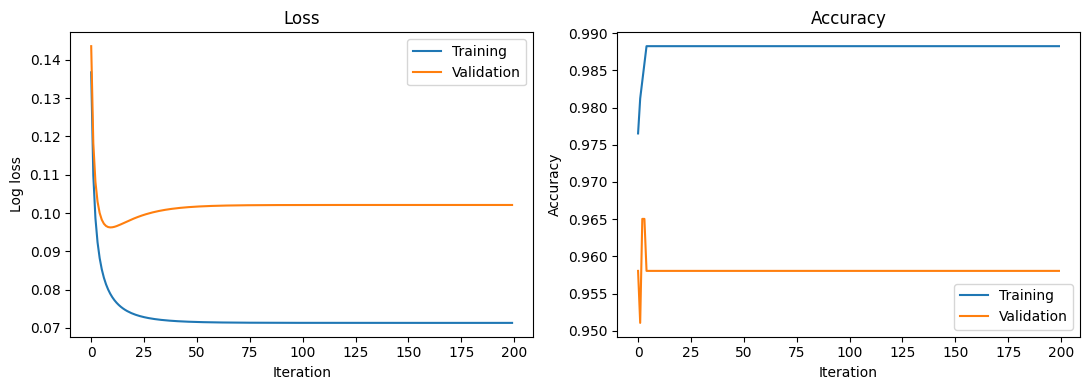

In [121]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
ax1.plot(train_loss, label='Training')
ax1.plot(test_loss, label='Validation')
ax1.set_title('Loss')
ax1.set_xlabel('Iteration')
ax1.set_ylabel('Log loss')
ax1.legend()

ax2.plot(train_acc, label='Training')
ax2.plot(test_acc, label='Validation')
ax2.set_title('Accuracy')
ax2.set_xlabel('Iteration')
ax2.set_ylabel('Accuracy')
ax2.legend()
plt.tight_layout()
plt.show()

In [122]:
Y_pred = classifier.predict(X_test)

In [123]:
cnf_matrix = confusion_matrix(Y_test, Y_pred)
cnf_matrix

array([[88,  2],
       [ 4, 49]])

In [124]:
accuracy = metrics.accuracy_score(Y_test, Y_pred)
precision = metrics.precision_score(Y_test, Y_pred)
recall = metrics.recall_score(Y_test, Y_pred)
f1 = metrics.f1_score(Y_test, Y_pred)

print("Accuracy:",accuracy)
print("Precision:",precision)
print("Recall:",recall)
print("F1:",f1)

Accuracy: 0.958041958041958
Precision: 0.9607843137254902
Recall: 0.9245283018867925
F1: 0.9423076923076923


Text(0.5, 427.9555555555555, 'Predicted label')

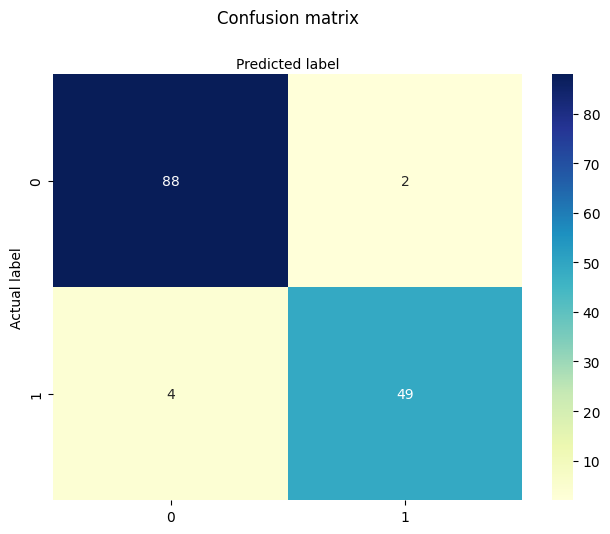

In [125]:
class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)
sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')